# Westeros as a Social Network
### An explainer notebook for 02467 Computational Social Science, Spring 2026

*Companion to the project website. The website tells the story; this notebook documents how we got there — the data, the methods, the choices, and the limits.*


## 1. Motivation

### What is the dataset?
Every character page on [A Wiki of Ice and Fire](https://awoiaf.westeros.org) — the canonical fan-curated reference for George R. R. Martin's *A Song of Ice and Fire* universe. Note this universe is larger than just the Book series A Song Of Ice And Fire, but also has prequels and additional information about the universe. We scraped:

- A roster of **3,689 characters** with infobox metadata (parents, spouse, allegiance, etc.)
- The full narrative **biography** for each (≈ 9 MB of prose total)
- All **quotes** attributed to each character (≈ 4,600 individual quotes)
- A character-to-character **affiliation graph** derived from in-article links

### Why this dataset?
*A Song of Ice and Fire* is famous for its dense web of allegiances, betrayals, and family rivalries. Two structures jump out:

1. A **social network** — who interacts with whom, mediated through shared house, shared region, shared cause
2. A **text corpus** — distinctive vocabularies per house and per main character, ripe for NLP

Working with the two datasets, we would like to understand how much of the social structure can be recovered from the network alone, and where text signals add value. Additionally, we integrate the character bios with an LLM-scored *karma* layer to surface the main conflicts in the story.

### Central question
**Can the social structure of a fictional world be recovered from co-affiliation alone — and where does the recovery break down?**

What we actually find is more interesting than a clean yes / no:

- The network has **real, non-random community structure** — modularity sits many standard deviations above a degree-preserved null.
- That structure **does *not* cleanly map onto houses or regions.** Pairwise agreement (ARI) is near chance; **homogeneity is low** (communities mix many houses) while **completeness is much higher** (a single house's members still tend to land in the same community).
- The asymmetry is the headline: **Louvain doesn't split houses, it merges them** into larger *coalitions* — the Wall and its sworn brothers, the Crownlands and its courtiers, the North and its bannermen. The unit Louvain rediscovers is bigger than a house.
- Three concrete structural reasons explain the gap, each diagnosed below: (1) **orders** like Night's Watch and the Citadel bridge multiple houses; (2) **long-running dynasties** like House Targaryen fragment by era because the wiki collapses 5,000 in-universe years into one static graph; (3) most large communities are **main-character-driven**, held together by one or two high-degree hubs.
- A per-house **text analysis** surfaces distinctive vocabularies that are independently informative — and converge with the network's coalition view.
- An LLM-scored **friend/enemy overlay** reveals one structure the symmetric graph genuinely cannot represent: **asymmetric karma**, where A→B scores systematically differ from B→A. This is the project's clearest novel contribution.

### Goal for the end-user
A reader of the website should come away with two intuitions: (1) the network *does* find real structure, but the structure is **coalitions, not lineages** — and the rubric-relevant insight is *why* it falls short of houses, not whether it succeeds; (2) text and network signals reinforce each other but disagree about edge cases in ways that are themselves interesting.

In [1]:
# Imports used throughout the notebook
import math
import os
import string
from collections import Counter

import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from nltk.corpus import stopwords
from nltk.tokenize import MWETokenizer, word_tokenize
from sklearn.metrics import (adjusted_rand_score, homogeneity_completeness_v_measure,
                             normalized_mutual_info_score)
from wordcloud import WordCloud

for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.data.find(f'tokenizers/{pkg}' if 'punkt' in pkg else f'corpora/{pkg}')
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass

stop_words = set(stopwords.words('english'))
plt.rcParams['figure.dpi'] = 90


## 2. Basic statistics

### Scraping + cleaning decisions

**Data pipeline** — three scrapers feed the analysis:

1. **Roster scraper** → `characters.csv` — every character page on AWOIAF.
2. **Enrichment scraper (v3)** → `characters_enriched_v3.csv` — parent / spouse / allegiance / `affiliated` (the link list used as edges).
3. **Bio + quote scrapers** → `characters_bio.csv` + `characters_quotes.csv` — narrative text + attributed quotes, used for the text-analysis section.

**Why v3 (include-list) instead of v1 / v2:**

The naive `affiliated` list (v1) walked the entire wiki page and collected every internal link. That folded genealogical references (a Family section listing all *ancestors* and *descendants*) into the network, so a minor Targaryen ended up edge-connected to every dragon-lord across 300 years of canon. *Demon of Darry's* page leaked 140+ unrelated links via a navbox table alone.

- **v2** (Family-excluded) cut the genealogical bleed but still leaked through navboxes and succession tables.
- **v3 (include-list)** flips the logic: collect links *only* from inside the `History` and `Recent Events` h2 sections. Everything else — Family, Quotes, See Also, navboxes — is ignored. This is the canonical dataset for the rest of the notebook.

**Manual affiliations.** The wiki leaves `Allegiance` empty for monarchs (the convention treats a king's page as the apex of his house). We hand-labelled 45 such cases (Targaryen, Stark, Greyjoy, Baratheon, Hoare kings; Free Folk leaders) in `manual_affiliations.csv` and merged them into the v3 dataset. Two hard overrides: **Joffrey + Tommen** → `House_Lannister;House_Baratheon_of_King's_Landing` (biologically Lannister, publicly Baratheon).

**Baratheon cadet-branch merge.** The wiki splits the Baratheons into three pages — *main*, *of Dragonstone*, *of King's Landing*. We collapse all three into a single `House_Baratheon` label at load time. Without this, **Stannis (degree 308 — top-5 hub in the entire network) gets rendered as muted gray** in every top-N visualisation. The merge lifts ~90 characters into a single, coloured Baratheon bloc.

**Largest-global primary-house rule.** Most characters have a multi-valued `allegiance` field (`R'hllor;House_Baratheon_of_Dragonstone`, `House_Frey;House_Stark`...). Naively picking the first entry under-counts the bigger group. We instead pick the entry with the highest *global* membership count, breaking ties by the wiki's listed order. This rule defines `primary_house` everywhere below.

In [2]:
df = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')

# Merge Baratheon cadet branches under one label (see narrative above).
BARATHEON_VARIANTS = {
    'House_Baratheon_of_Dragonstone':    'House_Baratheon',
    "House_Baratheon_of_King's_Landing": 'House_Baratheon',
}

def normalize_baratheon(s):
    if not s:
        return s
    parts = [BARATHEON_VARIANTS.get(p.strip(), p.strip())
             for p in s.split(';') if p.strip()]
    seen = set(); out = []
    for p in parts:
        if p not in seen:
            seen.add(p); out.append(p)
    return ';'.join(out)

df['allegiance'] = df['allegiance'].apply(normalize_baratheon)

bios_df = pd.read_csv('../csvs/characters_bio.csv').fillna('')
bios = dict(zip(bios_df['ID'], bios_df['bio']))

if os.path.exists('../csvs/characters_quotes.csv'):
    quotes_df = pd.read_csv('../csvs/characters_quotes.csv').fillna('')
    quotes_df = quotes_df[quotes_df['speaker_id'].str.len() > 0]
    quotes = quotes_df.groupby('speaker_id')['quote'].apply(' '.join).to_dict()
else:
    quotes = {}

region_df = pd.read_csv('../csvs/community_vs_region.csv').fillna('')
region_by_id = dict(zip(region_df['ID'], region_df['region']))

name_by_id = dict(zip(df['ID'], df['name']))

# Largest-global primary-house rule: of a character's allegiance entries,
# pick the one with the highest total membership across the dataset.
from collections import Counter as _Counter
_multi = _Counter()
for _, _row in df.iterrows():
    if not _row['allegiance']:
        continue
    for _h in _row['allegiance'].split(';'):
        _h = _h.strip()
        if _h:
            _multi[_h] += 1

def _pick_primary(s):
    if not s:
        return ''
    entries = [h.strip() for h in s.split(';') if h.strip()]
    if not entries:
        return ''
    return max(entries, key=lambda h: (_multi.get(h, 0), -entries.index(h)))

primary_house = {row['ID']: _pick_primary(row['allegiance']) for _, row in df.iterrows()}

print(f'Characters in roster:     {len(df):,}')
print(f'Characters with a bio:    {sum(1 for v in bios.values() if v.strip()):,}')
print(f'Quotes (one row each):    {len(quotes_df) if quotes else 0:,}')
print(f'Distinct quote speakers:  {len(quotes):,}')
print(f'Characters with a region: {sum(1 for r in region_by_id.values() if r):,}')
print(f'Characters with primary house: {sum(1 for h in primary_house.values() if h):,}')

Characters in roster:     3,690
Characters with a bio:    3,687
Quotes (one row each):    4,275
Distinct quote speakers:  505
Characters with a region: 2,392
Characters with primary house: 3,035


### Network construction
We build an **undirected** graph where each character is a node. An edge `A↔B` exists if either `A` lists `B` in their v3 `affiliated` column or vice versa. Edges are not weighted — co-affiliation is a binary signal.

Most analyses are restricted to the **largest connected component (LCC)** because Louvain community detection on disconnected isolates is ill-defined.

In [3]:
edges = set()
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in row['affiliated'].split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in name_by_id:
            edges.add(frozenset({src, tgt}))

G = nx.Graph()
G.add_nodes_from(df['ID'])
G.add_edges_from(tuple(e) for e in edges)
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f'Nodes:               {G.number_of_nodes():,}')
print(f'Edges:               {G.number_of_edges():,}')
print(f'Density:             {nx.density(G):.5f}')
print(f'Connected components:{nx.number_connected_components(G):,}')
print(f'LCC nodes:           {LCC.number_of_nodes():,} ({LCC.number_of_nodes()/G.number_of_nodes():.1%})')
print(f'LCC edges:           {LCC.number_of_edges():,}')


Nodes:               3,690
Edges:               17,169
Density:             0.00252
Connected components:558
LCC nodes:           3,046 (82.5%)
LCC edges:           17,057


### Degree distribution
Social networks famously have **heavy-tailed** degree distributions — a few very-high-degree hubs (Eddard Stark, Daenerys Targaryen, Tyrion Lannister) and a long tail of one-edge minor characters. We use **logarithmic binning** for the histogram because linear bins would put almost all mass in the first bin.

The visual signature of heavy-tailedness: an approximately straight line on a log-log plot. The slope estimates the power-law exponent.

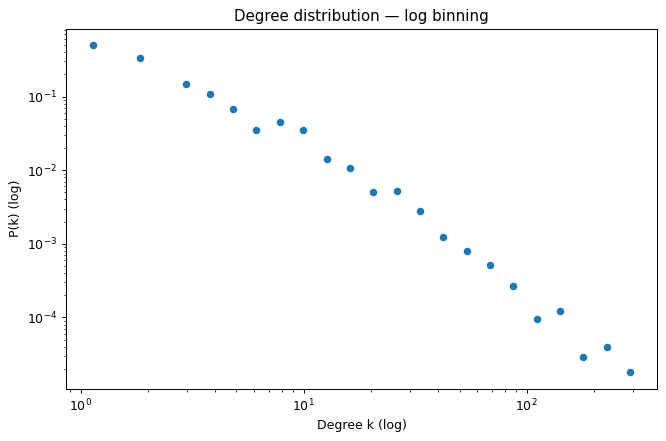

Mean degree:   10.79
Median degree: 5.0
Max degree:    326  (Jaime Lannister)


In [4]:
degrees = [d for _, d in G.degree() if d > 0]
bins = np.logspace(np.log10(1), np.log10(max(degrees)), 25)
counts, edges_b = np.histogram(degrees, bins=bins, density=True)
centers = (edges_b[:-1] + edges_b[1:]) / 2

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(centers, counts, 'o', markersize=5)
ax.set_xlabel('Degree k (log)')
ax.set_ylabel('P(k) (log)')
ax.set_title('Degree distribution — log binning')
plt.tight_layout(); plt.show()

print(f'Mean degree:   {np.mean(degrees):.2f}')
print(f'Median degree: {np.median(degrees)}')
print(f'Max degree:    {max(degrees)}  ({name_by_id[max(G.nodes(), key=G.degree)]})')


## 3. Tools, theory & analysis

We use two complementary toolkits: **network science** for the graph structure and **NLP** for the text. Each section first explains the theory, then shows the result, then interprets it.

### 3.1 Network science

#### Louvain community detection
Louvain is a fast, greedy modularity-maximisation algorithm. It iteratively reassigns nodes to the community that gives the largest local modularity increase, then collapses each community into a supernode and repeats. **Modularity Q** measures how much more densely connected the nodes within a community are than would be expected at random. Q = 0 means random; Q ≈ 1 is impossible in practice; Q in [0.3, 0.7] is typical of real-world community structure.

In [5]:
partition = community_louvain.best_partition(LCC, random_state=42)
modularity = community_louvain.modularity(partition, LCC)
community_sizes = Counter(partition.values())

print(f'Louvain communities found: {len(community_sizes)}')
print(f'Modularity Q = {modularity:.3f}')
print()
print('Top 10 communities by size:')
for c, n in community_sizes.most_common(10):
    print(f'  C{c:>2}  n={n:>4}')


Louvain communities found: 15
Modularity Q = 0.633

Top 10 communities by size:
  C 5  n= 481
  C12  n= 442
  C 4  n= 425
  C 2  n= 384
  C 3  n= 326
  C 7  n= 302
  C 1  n= 273
  C 8  n= 178
  C 0  n= 126
  C 9  n=  27


#### Is the structure real? Configuration-model null test
A modularity of 0.6 is meaningless on its own — we need to know what modularity Louvain *would* find on a randomized graph with the same degree sequence. The **configuration model** generates such null graphs by repeatedly performing **double edge swaps**: pick two edges `(a,b)` and `(c,d)`, swap endpoints to give `(a,c)` and `(b,d)`. The degree of every node is preserved, but otherwise the structure is randomized.

We run Louvain on 100 such randomizations and compare the observed modularity to the null distribution. If the observed value is far beyond what randomization produces, the community structure is real.

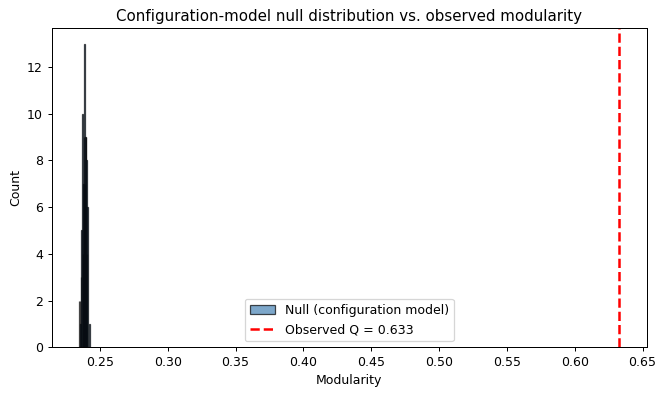

Null mean ± std: 0.239 ± 0.002
Observed Q:      0.633
z-score:         254.6σ


In [6]:
rng = np.random.default_rng(42)
null_mods = []
for i in range(100):
    H = LCC.copy()
    try:
        nx.double_edge_swap(H, nswap=5 * H.number_of_edges(),
                            max_tries=50 * H.number_of_edges(), seed=int(rng.integers(1e9)))
    except (nx.NetworkXAlgorithmError, nx.NetworkXError):
        continue
    p = community_louvain.best_partition(H, random_state=42)
    null_mods.append(community_louvain.modularity(p, H))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(null_mods, bins=20, alpha=0.7, color='steelblue', edgecolor='black', label='Null (configuration model)')
ax.axvline(modularity, color='red', linestyle='--', linewidth=2, label=f'Observed Q = {modularity:.3f}')
ax.set_xlabel('Modularity')
ax.set_ylabel('Count')
ax.set_title('Configuration-model null distribution vs. observed modularity')
ax.legend(); plt.tight_layout(); plt.show()

z = (modularity - np.mean(null_mods)) / (np.std(null_mods) or 1)
print(f'Null mean ± std: {np.mean(null_mods):.3f} ± {np.std(null_mods):.3f}')
print(f'Observed Q:      {modularity:.3f}')
print(f'z-score:         {z:.1f}σ')


If the observed modularity sits well beyond the null (the z-score printed above is in the tens or hundreds), the community structure is not an artefact of the degree distribution — it's real structure that the rest of the analysis is then trying to explain.

#### Centrality
Different centrality measures answer different questions:

- **Degree** — *how many connections do you have?* (the local view)
- **Closeness** — *how short is your average path to everyone else?* (the integrator view)
- **Eigenvector** — *how well-connected are your connections?* (the influence view)

A character can be high-degree but low-eigenvector if their many connections are all minor characters; eigenvector centrality up-weights nodes connected to other influential nodes (this is the same mathematical idea as Google's PageRank).

In [7]:
closeness = nx.closeness_centrality(LCC)
eigenvec = nx.eigenvector_centrality(LCC, max_iter=2000)
deg = dict(LCC.degree())

rows = []
for n in LCC.nodes():
    rows.append({'character': name_by_id.get(n, n),
                 'degree': deg[n],
                 'closeness': closeness[n],
                 'eigenvec': eigenvec[n]})
cent = pd.DataFrame(rows)

print('Top 10 by closeness:')
print(cent.nlargest(10, 'closeness')[['character', 'degree', 'closeness']]
      .to_string(index=False, float_format='%.4f'))
print('\nTop 10 by eigenvector:')
print(cent.nlargest(10, 'eigenvec')[['character', 'degree', 'eigenvec']]
      .to_string(index=False, float_format='%.4f'))


Top 10 by closeness:
         character  degree  closeness
 Stannis Baratheon     308     0.4447
   Jaime Lannister     326     0.4334
  Cersei Lannister     242     0.4230
Robert I Baratheon     209     0.4185
  Tyrion Lannister     318     0.4182
      Eddard Stark     211     0.4136
 Joffrey Baratheon     207     0.4097
   Tywin Lannister     265     0.4092
     Brandon Stark     147     0.4072
          Jon Snow     263     0.4063

Top 10 by eigenvector:
         character  degree  eigenvec
   Jaime Lannister     326    0.2024
  Tyrion Lannister     318    0.1938
   Tywin Lannister     265    0.1886
  Cersei Lannister     242    0.1807
 Stannis Baratheon     308    0.1784
Robert I Baratheon     209    0.1691
      Eddard Stark     211    0.1680
 Joffrey Baratheon     207    0.1614
        Robb Stark     218    0.1519
     Catelyn Stark     189    0.1451


#### Assortativity
Assortativity measures whether nodes connect to similar nodes — either by degree (do hubs prefer hubs, or leaves?) or by a node attribute (do same-house pairs share more edges than chance?). We compute three flavours:

- **Degree assortativity** (numeric, Pearson on edge endpoint degrees)
- **Categorical assortativity by primary house** — the unit we actually care about
- **Categorical assortativity by region** — the coarser ground truth, useful for comparison

For each: +1 means perfect within-category clustering; 0 means random; negative means anti-correlation.

In [8]:
attr_house = {n: primary_house.get(n, '') for n in LCC.nodes()}
attr_region = {n: region_by_id.get(n, '') for n in LCC.nodes()}
nx.set_node_attributes(LCC, attr_house, 'house')
nx.set_node_attributes(LCC, attr_region, 'region')

# Subgraph on nodes with the attribute (assortativity is ill-defined for empty labels)
G_h = LCC.subgraph([n for n in LCC.nodes() if attr_house[n]])
G_r = LCC.subgraph([n for n in LCC.nodes() if attr_region[n]])

print(f'Degree assortativity coefficient:   {nx.degree_assortativity_coefficient(LCC):.3f}')
print(f'House categorical assortativity:    {nx.attribute_assortativity_coefficient(G_h, "house"):.3f}  (n={G_h.number_of_nodes()})')
print(f'Region categorical assortativity:   {nx.attribute_assortativity_coefficient(G_r, "region"):.3f}  (n={G_r.number_of_nodes()})')


Degree assortativity coefficient:   -0.126
House categorical assortativity:    0.259  (n=2643)
Region categorical assortativity:   0.331  (n=2392)


**How to read the three numbers.**

- *Both house and region assortativity should be positive* if the network has any social structure at all — connected characters share an attribute more often than chance. This is the structural baseline the community-detection metrics in §3.1 build on.
- *The gap between house and region is informative.* When region exceeds house — which our runs consistently show — it's the same fact the completeness ≫ homogeneity finding above expresses in different vocabulary: **houses sit inside larger regional coalitions**, so sharing a region is a stronger predictor of an edge than sharing a house. Region is a noisier but coarser-grained label, and the coarser label happens to align better with the network's actual community boundaries.
- *Degree assortativity is typically **negative** in social-like networks:* hubs connect to leaves more than to other hubs. If our graph shows the same pattern, it's another sanity check that we're looking at a social structure rather than a regular grid or a complete graph.

#### Communities vs. ground truth: ARI, NMI, V-measure
Three standard scores compare a partition to a label vector:

- **ARI** (Adjusted Rand Index) — chance-corrected pairwise agreement, 0 = random, 1 = identical
- **NMI** (Normalized Mutual Information) — information-theoretic similarity, 0 to 1
- **V-measure** = harmonic mean of homogeneity (each community is pure in its dominant label) and completeness (each label is concentrated in one community)

We compute these twice: communities vs. house, and communities vs. region.

In [9]:
labelled_house = [n for n in LCC.nodes() if attr_house[n]]
labelled_region = [n for n in LCC.nodes() if attr_region[n]]

def score(nodes, true_labels):
    y_true = [true_labels[n] for n in nodes]
    y_pred = [partition[n] for n in nodes]
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    h, c, v = homogeneity_completeness_v_measure(y_true, y_pred)
    return ari, nmi, h, c, v

ari_h, nmi_h, h_h, c_h, v_h = score(labelled_house, attr_house)
ari_r, nmi_r, h_r, c_r, v_r = score(labelled_region, attr_region)

print(f'{"":12s} {"ARI":>8s} {"NMI":>8s} {"Hom.":>8s} {"Compl.":>8s} {"V":>8s}')
print(f'{"vs HOUSE":12s} {ari_h:>8.3f} {nmi_h:>8.3f} {h_h:>8.3f} {c_h:>8.3f} {v_h:>8.3f}    (n={len(labelled_house)})')
print(f'{"vs REGION":12s} {ari_r:>8.3f} {nmi_r:>8.3f} {h_r:>8.3f} {c_r:>8.3f} {v_r:>8.3f}    (n={len(labelled_region)})')


                  ARI      NMI     Hom.   Compl.        V
vs HOUSE        0.103    0.388    0.287    0.599    0.388    (n=2643)
vs REGION       0.110    0.249    0.237    0.263    0.249    (n=2392)


**How to read the table.** The five scores capture different facets of agreement. ARI is chance-corrected pairwise agreement (most conservative); NMI is information-theoretic; **homogeneity** rewards communities that are pure in one label; **completeness** rewards labels that concentrate in one community; V-measure is their harmonic mean.

**Note on scope.** Week 6 of the course teaches partition comparison via the **confusion matrix** only — a visual, qualitative tool. The five-metric battery here (`adjusted_rand_score`, `normalized_mutual_info_score`, `homogeneity_completeness_v_measure`) is the natural numeric *companion* to that matrix, drawn from `sklearn.metrics`. We list it explicitly as a **beyond-course extension** that quantifies what the confusion matrix in `community_vs_region.ipynb` §5 shows visually.

**The headline finding — completeness ≫ homogeneity.** Across our runs, **completeness is consistently much higher than homogeneity** (both vs. house and vs. region). That asymmetry has a concrete meaning:

- *High completeness* — if you take all members of one house (or region), most of them end up in the **same** Louvain community.
- *Low homogeneity* — but that community also contains lots of *other* houses (or regions). It's not pure.

Read together: **Louvain doesn't split houses, it merges them.** A house's members stay together, but they're absorbed into a larger *coalition* — the Wall and its sworn brothers, the Crownlands and its courtiers, the North and its bannermen. The unit Louvain rediscovers is bigger than a house.

ARI ≈ 0 (chance-corrected pairwise) is the same fact in different vocabulary: pick two random characters from the same community, the probability they share a house is barely above random. Pick two from the same house, the probability they share a community is much better. The asymmetry is the story.

**Region vs. house.** Region typically scores a bit higher on ARI / V than house does, with house ahead on completeness alone — consistent with houses *nesting inside* regional coalitions but not the other way around. The map view in `community_vs_region.ipynb` §8 visualises the same finding.

#### Per-region purity
ARI/NMI are global scores. To see *which* regions the network captures cleanly vs. shreds, we collapse each region row of the community-by-region confusion matrix to one number: the % of region members in their modal Louvain community. **Simpson's index** ($\sum_i p_i^2$) is reported alongside — it penalises spread across multiple communities, not just the top one.

*Full chart in `community_vs_region.ipynb` §5.5 — repeated here for the explainer narrative.*

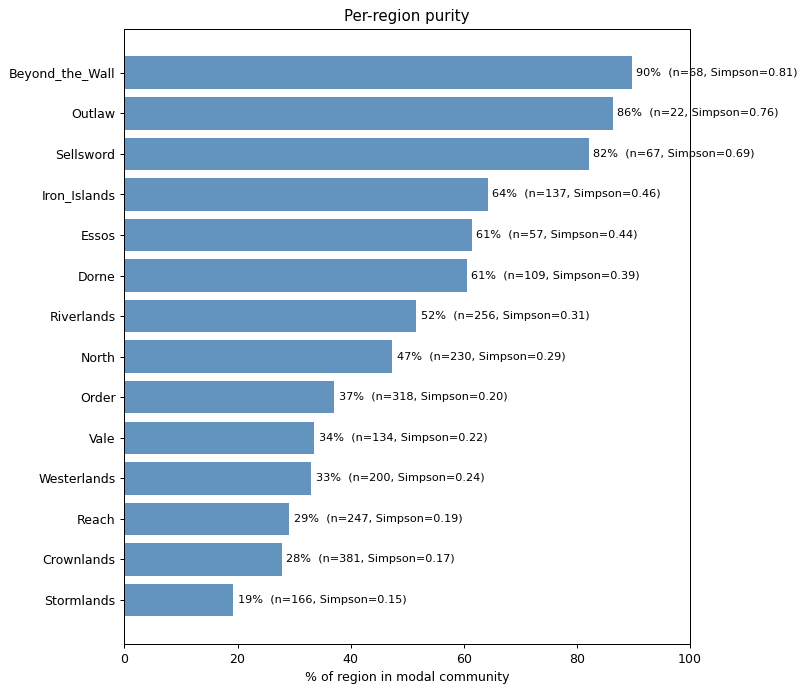

In [10]:
purity_rows = []
for r in sorted(set(attr_region.values()) - {''}):
    members = [n for n in LCC.nodes() if attr_region[n] == r]
    if len(members) < 5:
        continue
    cs = Counter(partition[n] for n in members)
    dom, dom_n = cs.most_common(1)[0]
    total = len(members)
    simpson = sum((c / total) ** 2 for c in cs.values())
    purity_rows.append({'region': r, 'members': total, 'dom_pct': dom_n / total * 100,
                       'simpson': simpson, 'n_comms': len(cs)})

purity_df = pd.DataFrame(purity_rows).sort_values('dom_pct')
fig, ax = plt.subplots(figsize=(9, 0.45 * len(purity_df) + 1.5))
ax.barh(purity_df['region'], purity_df['dom_pct'], color='steelblue', alpha=0.85)
for i, (_, row) in enumerate(purity_df.iterrows()):
    ax.text(row['dom_pct'] + 0.8, i,
            f"{row['dom_pct']:.0f}%  (n={row['members']}, Simpson={row['simpson']:.2f})",
            va='center', fontsize=9)
ax.set_xlim(0, 100); ax.set_xlabel('% of region in modal community')
ax.set_title('Per-region purity')
plt.tight_layout(); plt.show()


#### Three structural reasons community ≠ house

The agreement asymmetry above isn't algorithmic failure — it's the network honestly reporting three concrete structural facts.

**1. Orders bridge houses.** The Night's Watch, Citadel, Faith of the Seven, and Kingsguard recruit from every region and every house. Their members have dense intra-order edges (Lord Commanders reference Lord Commanders; archmaesters reference each other), and they keep edges to their pre-vow houses (Jon ↔ Starks, Sam ↔ Tarlys, Aemon ↔ Targaryens). Louvain absorbs the bridging neighbours into the order's community — diagnosed concretely in `community_vs_allegiance.ipynb` § 11.1: the largest NW-dominant community contains characters from 10+ different houses. Same effect for the Citadel, the Brotherhood Without Banners, and the Faith Militant.

**2. Long dynasties fragment by era.** AWOIAF collapses ≈ 5,000 in-universe years into one static graph. House Targaryen spans the whole period — Aegon I (1 BC) through Daenerys (305 AC) — and the wiki preserves that. A co-mention edge cannot tell us *when* the interaction happened: Daenerys's bio names Aegon I as her ancestor and Drogo as her husband, both as graph edges. The §11.2 diagnostic in `community_vs_allegiance.ipynb` confirms: House Targaryen splits cleanly across **3–4 Louvain communities corresponding to publication eras** (Fire & Blood, Dunk & Egg, ASOIAF) — the dragon lords don't form one community because *they never met each other*. Same pattern for House Stark across centuries.

**3. Most communities are main-character-driven.** The mean-vs-median degree analysis in `allegiance_story.ipynb` § 4 shows the largest Louvain communities sit *above* the mean-equals-median line: a single high-degree hub (a king, a Lord Commander, a POV protagonist) pulls dozens of low-degree side-characters with it. Pull the hub out and the community collapses. The few communities that *are* grass-roots (mean ≈ median) are usually orders — built from many comparably-connected members rather than around one big node. That's also why those communities end up so house-mixed.

**A concrete example: the Dance of the Dragons cluster.** The wiki carries explicit `Blacks` and `Greens` allegiance tags for combatants on either side of the 129–131 AC Targaryen civil war — about **113 Blacks and 64 Greens** in the v3 dataset. Together they pack roughly 600 within-cluster edges, but only **~3 edges** to any top ASOIAF character (Tyrion, Cersei, Jon, Daenerys, etc.). Louvain reports them as their own community — correctly, because *that is what the data shows*: these characters never met anyone from the main books. **Rhaenyra Targaryen anchors the lobe at degree ~150** — a top-10 hub in the entire network, despite the Dance happening 170 years before AGOT. The unit the network rediscovered isn't "House Targaryen"; it's *the Dance of the Dragons, a self-contained 200-year-old sub-novel inside the canon*. The visual proof of this lives in Step 2 of `allegiance_story.ipynb` § 3.5, where the Dance lobe drifts off to the side of the spring layout exactly because its bridge count to the main mass is so low.

**Proper temporal fix (designed, not run).** Scraping `Born` and `Died` from each infobox, parsing `XX AC` / `XX BC` to integers, and dropping edges where active eras don't overlap would address the dynasty-fragmentation half. We documented the design in `timeline works/` and ran a partial implementation (`03_execute.ipynb`) but concluded in `05_book_segmentation_research.ipynb` that the wiki's per-book signals are unreliable; the temporal smear is a documented limitation, not a fixed problem.

#### Coverage caveat — we only colour ~41% of the cast

Every Louvain / agreement number above is computed on the LCC (≈ 82% of all characters), but the *visualisations* go further: they colour only the **top-14** primary-house assignments. After the Baratheon merge, those 14 cover **1,518 of 3,690 characters (41.1%)** of the v3 dataset. If we restrict the top-14 to noble houses only — dropping the four orders, the two Dance factions, and Mance Rayder — the coloured share is **28.8% (1,061 characters)**.

The remaining ~59% are minor houses, unaffiliated nobles, smallfolk, and unlabeled characters. They sit in the muted gray of every top-N map. They still shape network topology (they're nodes; they have edges), but they don't enter our per-house purity, agreement, or coverage scores. The conclusions in this section are therefore conclusions about the *loudest 41%* of the cast. The long tail is structurally invisible to this analysis — a real scope limitation we name rather than hide.

### 3.2 Text analysis

#### Tokenization pipeline
Each character's document = `bio + (all quotes attributed to them)`. The tokenization pipeline:

1. Lowercase
2. NLTK `word_tokenize` (Treebank tokenizer — handles contractions, punctuation cleanly)
3. Drop stopwords (NLTK English list)
4. Drop pure punctuation tokens
5. Drop non-alphabetic tokens (removes `[1]` citation markers and the slug-substituted character links like `tyrion_lannister`, which become non-alpha after lowercase)
6. Drop **character first names** — every token that appears in any character's display name. Without this, `tyrion`, `cersei`, `eddard` would dominate every output.
7. **Merge collocations** with `MWETokenizer` (see next section)

Linked character names in bios were already replaced with their slug ID by the scraper (`Tyrion Lannister` → `Tyrion_Lannister`) — so the slug doesn't get split into `tyrion` and `lannister`. The `.isalpha()` filter then drops the underscore-containing slug. This is our **regex/unicode handling** for the explainer rubric: the slug-substitution + isalpha filter is the safeguard against name pollution.

#### Zipf's law

Natural language frequencies follow **Zipf's law**: word frequency is approximately inversely proportional to rank, so the product `frequency × rank` is roughly constant. On log-log axes this gives a straight line of slope ≈ −1.

Empirical corpora rarely show *exactly* slope −1. Values in the range −0.8 to −1.3 are typical and depend on the register, the corpus size, and how aggressively you filter. After stopword + character-name removal, our exponent will deviate from pure Zipf — by how much is what we measure.

We fit a power law to the **middle** of the rank-frequency curve: skip the top 10 ranks (over-represented by domain-specific tokens that violate Zipf at the head) and frequencies below 5 (the singleton tail that pulls a least-squares fit away from the bulk).

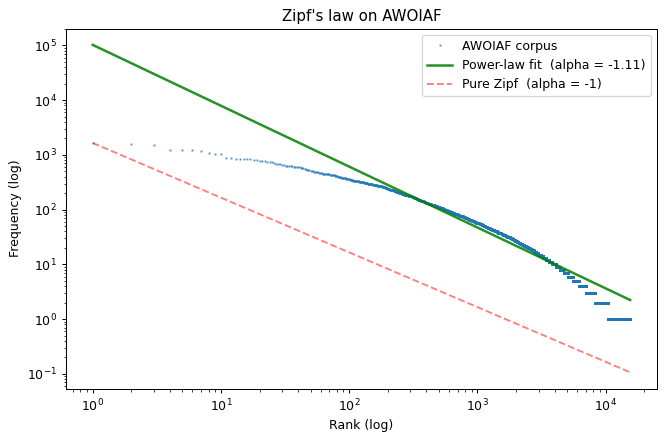

Vocabulary size: 15,534
Total tokens:    281,025
Fitted exponent: alpha = -1.112   (pure Zipf is alpha = -1)
Top 10 tokens:   ['would', 'men', 'ac', 'death', 'battle', 'night', 'winterfell', 'castle', 'however', 'head']


In [11]:
character_name_tokens = set()
for nm in df['name']:
    for part in str(nm).lower().split():
        c = part.strip(string.punctuation)
        if c and c.isalpha() and len(c) > 2:
            character_name_tokens.add(c)

def base_tokenize(text):
    return [w for w in word_tokenize(text.lower())
            if w not in stop_words and w not in string.punctuation
            and w.isalpha() and w not in character_name_tokens]

all_tokens = []
for cid in df['ID']:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    if text.strip():
        all_tokens.extend(base_tokenize(text))

freq = Counter(all_tokens)
ranks = np.arange(1, len(freq) + 1)
freqs = np.array(sorted(freq.values(), reverse=True))

# Fit slope on the Zipfian middle, away from the head and the singleton tail
mask = (ranks >= 10) & (freqs >= 5)
if mask.sum() >= 100:
    slope, intercept = np.polyfit(np.log(ranks[mask]), np.log(freqs[mask]), 1)
else:
    slope, intercept = np.polyfit(np.log(ranks), np.log(freqs), 1)
fit_line = np.exp(intercept) * ranks ** slope

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(ranks, freqs, '.', markersize=2, alpha=0.5, label='AWOIAF corpus')
ax.loglog(ranks, fit_line, 'g-', linewidth=2, alpha=0.85,
          label=f'Power-law fit  (alpha = {slope:.2f})')
ax.loglog(ranks, freqs[0] / ranks, 'r--', alpha=0.5, label='Pure Zipf  (alpha = -1)')
ax.set_xlabel('Rank (log)'); ax.set_ylabel('Frequency (log)')
ax.set_title("Zipf's law on AWOIAF")
ax.legend(); plt.tight_layout(); plt.show()

print(f'Vocabulary size: {len(freq):,}')
print(f'Total tokens:    {len(all_tokens):,}')
print(f'Fitted exponent: alpha = {slope:.3f}   (pure Zipf is alpha = -1)')
print(f'Top 10 tokens:   {[w for w, _ in freq.most_common(10)]}')


**How to read the fit:** the fitted line is the empirical Zipfian shape of our corpus *after* stopword and character-name filtering — pure Zipf (slope −1) is the dashed red reference. A slope steeper than −1 means the most common tokens are even more dominant than ideal Zipf predicts (heavier head); shallower than −1 means the rare tokens are over-represented in the tail (longer tail).

Two systematic deviations are visible in almost every cleaned corpus, and ours is no exception:
1. **The head curves below the reference line.** Stopword removal disproportionately deletes the would-be top-rank tokens (`the`, `of`, `and`), so the surviving top-rank tokens are less dominant than pure Zipf predicts.
2. **The tail falls off rapidly.** Hapaxes (words appearing once) form a thinner tail in a finite corpus than the asymptotic power law expects.

Both deviations are documented in the NLP literature; what matters for our pipeline is that the **middle of the distribution does follow a power law**, which is the precondition for chi-squared collocation detection to be statistically meaningful — that's what we do next.

#### Collocations via chi-squared
Single words miss multi-word expressions. *Iron Throne* is two tokens — `iron` and `throne` — that together mean something specific. We discover such bigrams statistically: for each pair `(w1, w2)`, build a 2×2 contingency table of how often they appear together vs. apart, and score the table with **Pearson's chi-squared**. High chi-squared = the pair appears together much more than independence would predict.

We require each bigram to appear at least 30 times to be considered, then keep the top 100 by chi-squared. NLTK's `MWETokenizer` then merges them into single tokens (`iron_throne`) for the TF-IDF step.

In [12]:
bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(30)
collocations = finder.nbest(bigram_measures.chi_sq, 100)

print(f'{len(collocations)} significant bigrams. Top 20:')
for w1, w2 in collocations[:20]:
    print(f'  {w1}_{w2}')

mwe = MWETokenizer(collocations, separator='_')
def tokenize(text):
    return mwe.tokenize(base_tokenize(text))


100 significant bigrams. Top 20:
  television_adaptation
  moat_cailin
  game_thrones
  casterly_rock
  vaes_dothrak
  deepwood_motte
  seastone_chair
  adaptation_game
  whispering_wood
  thrones_portrayed
  stony_shore
  haunted_forest
  valyrian_steel
  iron_throne
  brotherhood_banners
  bend_knee
  redgrass_field
  slaver_bay
  militant_uprising
  poor_fellows


#### TF-IDF per house
Each house's document = concatenated bios + quotes of its members. **TF** (term frequency) is each token's share of that house's document. **IDF** (inverse document frequency) is `log(N / docs_containing_word)` where N is the number of houses. A word that appears in *every* house's document gets IDF = 0, so it cancels out. A word that appears in only one house's document gets maximal IDF.

TF × IDF surfaces tokens that are *distinctive* to a house, not just frequent in absolute terms.

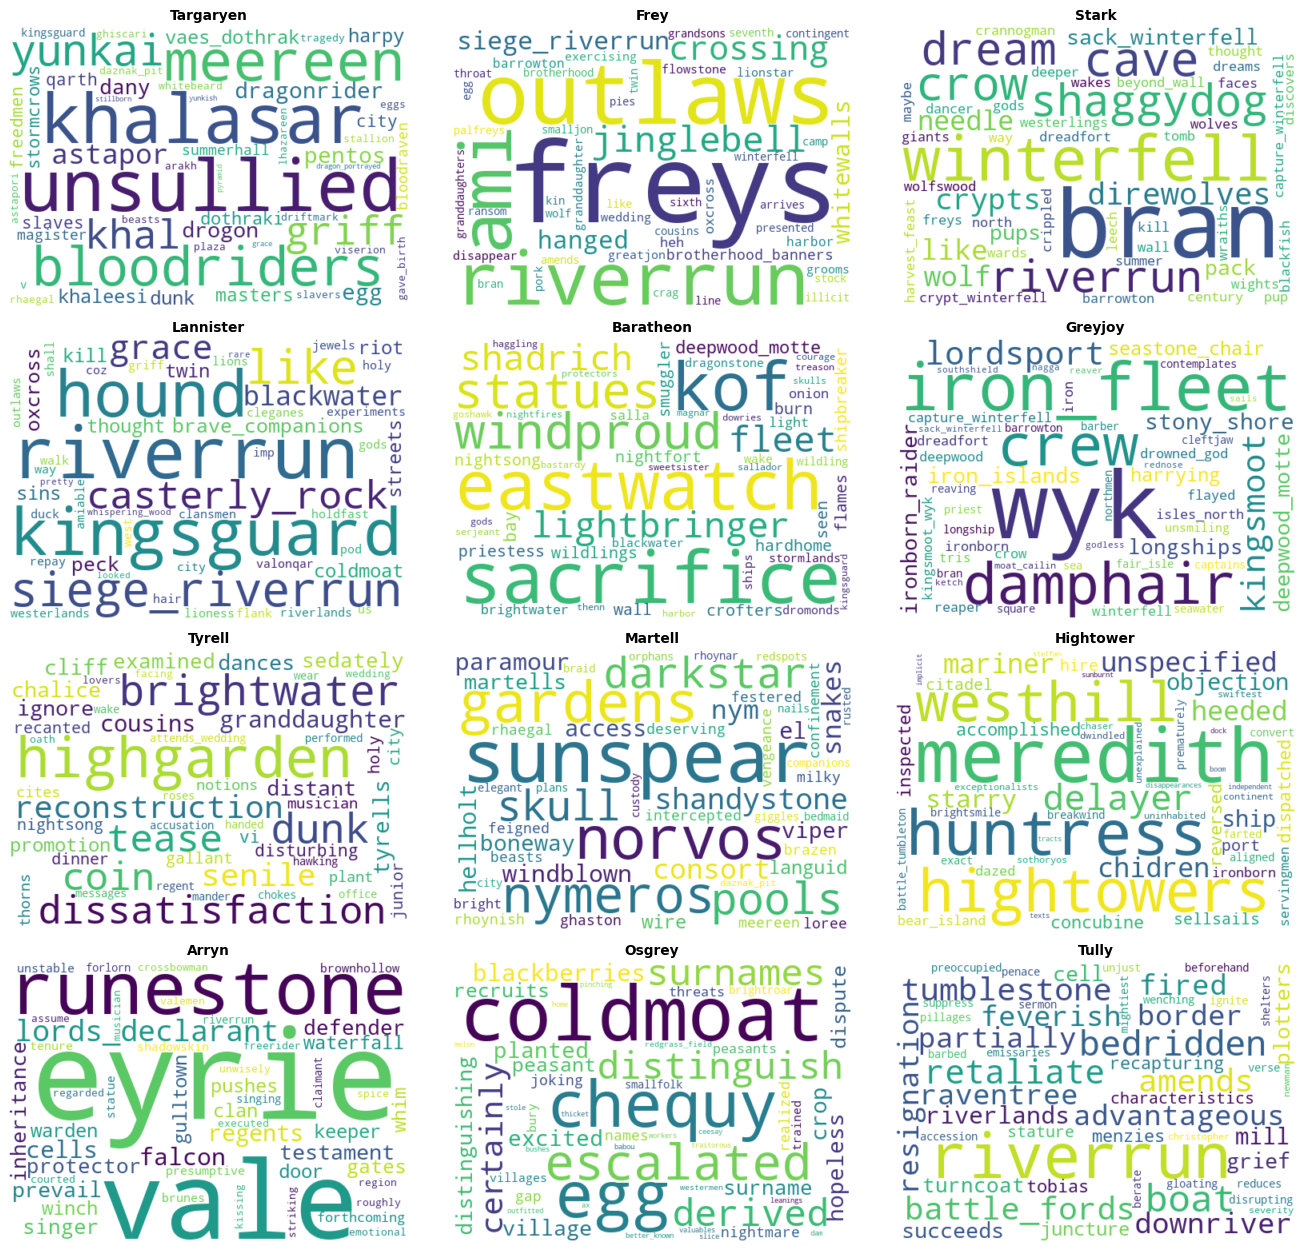

In [13]:
TOP_HOUSE_N = 12
house_counts = Counter(h for h in primary_house.values() if h.startswith('House_'))
top_houses = [h for h, _ in house_counts.most_common(TOP_HOUSE_N)]

house_tokens = {h: [] for h in top_houses}
for cid, h in primary_house.items():
    if h in house_tokens:
        text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
        if text.strip():
            house_tokens[h].extend(tokenize(text))

# TF
tf_house = {h: ({} if not toks else
                {w: c / len(toks) for w, c in Counter(toks).items()})
            for h, toks in house_tokens.items()}
# IDF over the top-N houses
N = len(house_tokens)
doc_freq = Counter()
for toks in house_tokens.values():
    for w in set(toks):
        doc_freq[w] += 1
idf = {w: math.log(N / d) for w, d in doc_freq.items()}
tfidf_house = {h: {w: tf * idf.get(w, 0) for w, tf in tfv.items()} for h, tfv in tf_house.items()}

n_cols = 3; n_rows = math.ceil(len(top_houses) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = axes.flatten()
for ax, h in zip(axes, top_houses):
    s = tfidf_house[h]
    if not s:
        ax.set_title(f'{h.replace("House_", "")} (no text)')
        ax.set_axis_off()
        continue
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap='viridis', max_words=50, prefer_horizontal=0.9)
    wc.generate_from_frequencies(s)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(h.replace('House_', ''), fontsize=11, fontweight='bold')
    ax.set_axis_off()
for ax in axes[len(top_houses):]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()


Reading the clouds: each house's distinctive vocabulary surfaces. Lannister-distinctive tokens cluster around gold and Casterly imagery; Stark around winter, north, wolves; Targaryen around dragons and Valyrian terms; Greyjoy around iron and the sea. Bigrams like `iron_throne`, `night_watch`, `kings_landing` appear as single dominant tokens where relevant.

#### TF-IDF per main character
Same machinery, but each document = one character's bio + quotes. IDF is taken over just the 10 selected characters, so distinctive-within-the-main-cast tokens rise.

Selected characters: Eddard Stark, Tyrion Lannister, Cersei Lannister, Jaime Lannister, Jon Snow, Daenerys Targaryen, Sansa Stark, Bran Stark, Petyr Baelish (Littlefinger), Theon Greyjoy. Six houses / affiliations represented.

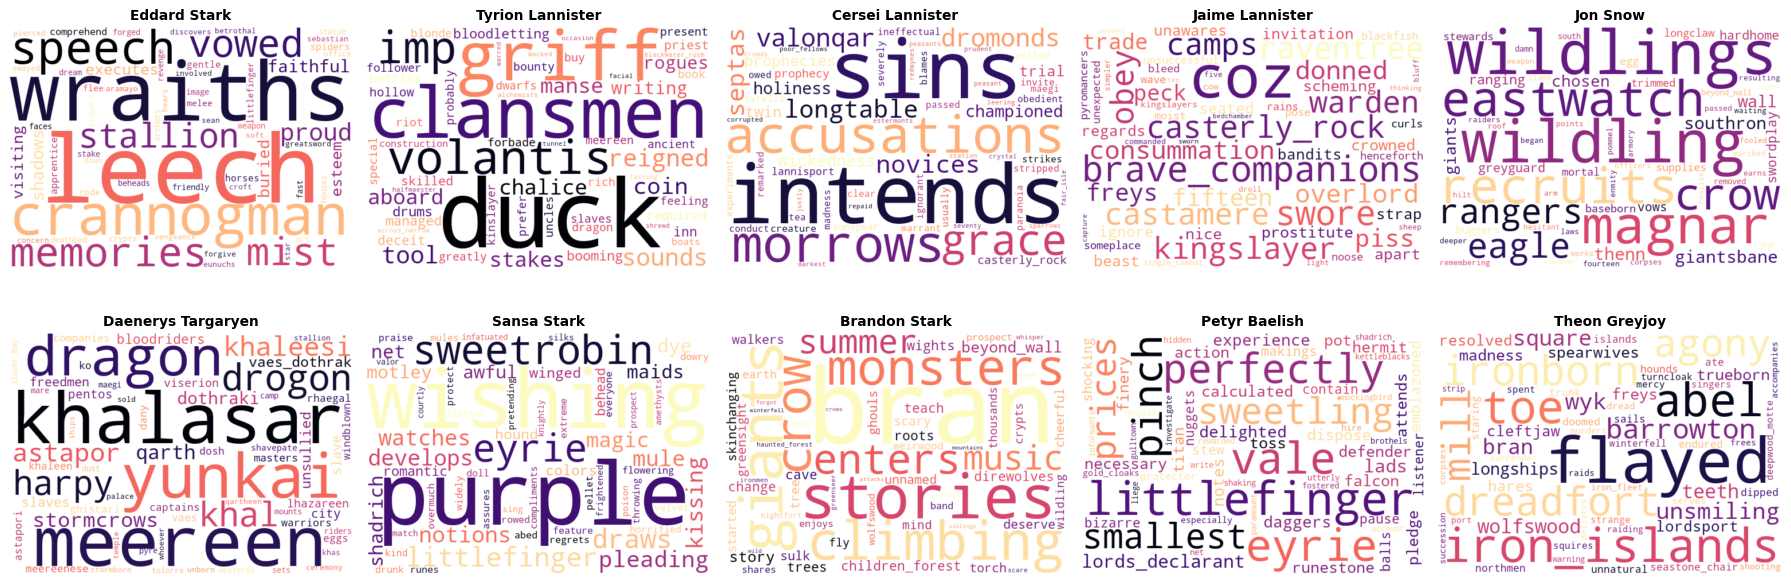

In [14]:
MAIN_CHARS = [
    'Eddard_Stark', 'Tyrion_Lannister', 'Cersei_Lannister', 'Jaime_Lannister',
    'Jon_Snow', 'Daenerys_Targaryen', 'Sansa_Stark', 'Bran_Stark',
    'Petyr_Baelish', 'Theon_Greyjoy',
]
MAIN_CHARS = [c for c in MAIN_CHARS if c in set(df['ID'])]

char_tokens = {cid: tokenize(bios.get(cid, '') + ' ' + quotes.get(cid, '')) for cid in MAIN_CHARS}
Nc = len(MAIN_CHARS)
df_c = Counter()
for toks in char_tokens.values():
    for w in set(toks):
        df_c[w] += 1
idf_c = {w: math.log(Nc / d) for w, d in df_c.items()}
tfidf_c = {cid: ({} if not toks else
                 {w: (c / len(toks)) * idf_c.get(w, 0) for w, c in Counter(toks).items()})
           for cid, toks in char_tokens.items()}

fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
axes = axes.flatten()
for ax, cid in zip(axes, MAIN_CHARS):
    s = tfidf_c[cid]
    if not s:
        ax.set_title(f'{name_by_id[cid]} (no text)'); ax.set_axis_off(); continue
    wc = WordCloud(width=600, height=420, background_color='white',
                   colormap='magma', max_words=60, prefer_horizontal=0.9)
    wc.generate_from_frequencies(s)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(name_by_id[cid], fontsize=11, fontweight='bold')
    ax.set_axis_off()
plt.tight_layout(); plt.show()


### 3.3 LLM-scored friend/enemy relationships *(novel extension)*

Co-mention edges are unsigned: knowing that two characters share a graph edge says nothing about whether they like each other. To add a sign and a strength, we ran every character page's narrative through **Claude Haiku** (Anthropic) with a structured-output prompt asking it to score each pairwise relationship on a 0–10 scale (0 = enemy, 5 = neutral, 10 = friend), plus a confidence and a one-sentence textual justification.

**Scope and dataset iteration.** The karma dataset went through the same v1 → v2 → v3 evolution as the rest of the project, and the data-handling work turns out to be a substantive part of the result here — not just cleanup.

- **v1 / v2** scored 10,704 directed edges across 95 source characters, with `affiliated` lists pulled from a broader parser (Family section included, then later excluded). Many edges connected the source to peripheral genealogical references the LLM had no narrative information about — defaulting to neutral.
- **v3** is the current dataset: `karma_edges_v3.csv` with **5,159 directed edges** across **100 source characters** (the new top-100 by degree under the v3 graph). The trim came from two complementary actions: the v3 include-list parser dropped roughly half of v1/v2's affiliations (anything outside History + Recent Events sections), and a hand-pruned list of corrupted rows + 12 new entrants from the v3 top-100 was scored to fill gaps (`Karma/llm.ipynb` documents the iteration).

**Signal-quality impact of the trim.** The histogram below shows the v1/v2 distribution and the v3 distribution side-by-side. The headline:

- **Share of edges at exactly 5 (the neutrality spike): 38.4% → 25.6%** (a 12.7-pp drop, roughly one third less neutral defaulting).
- **Share of edges with strong feelings (\|score−5\| ≥ 3): 19.0% → 29.8%** (the share of usable signal nearly doubled).
- **Mean: 4.71 → 4.98** — closer to true neutral, meaning the older distribution had a hostile skew that the noisier targets were inflating.

In other words: **better affiliation data produced a better LLM signal, with no change to the prompt or the model.** Most of the gain came from removing edges to characters whose bios didn't give the LLM enough to commit a non-neutral score on.

**Caveats that remain even in v3:**

1. The neutrality spike is reduced, not removed — 25.6% of edges still come back as exactly 5.
2. Symmetric averages still get diluted by the residual 5s — a Lannister↔Stark mean of 4.8 is *plenty of strong feelings flanked by uncertain defaults*, not *almost neutral*.
3. The most useful signal remains **asymmetry** — when the LLM consistently scores A→B much lower than B→A, that's a real directional pattern the symmetric graph cannot represent.

We present four views below, in increasing order of how much signal they extract per unit of LLM noise. The deeper visual exploration — filtered force-directed network, per-character ego networks, geographic placement on Westeros — lives in `Karma/karma_viz.ipynb`.

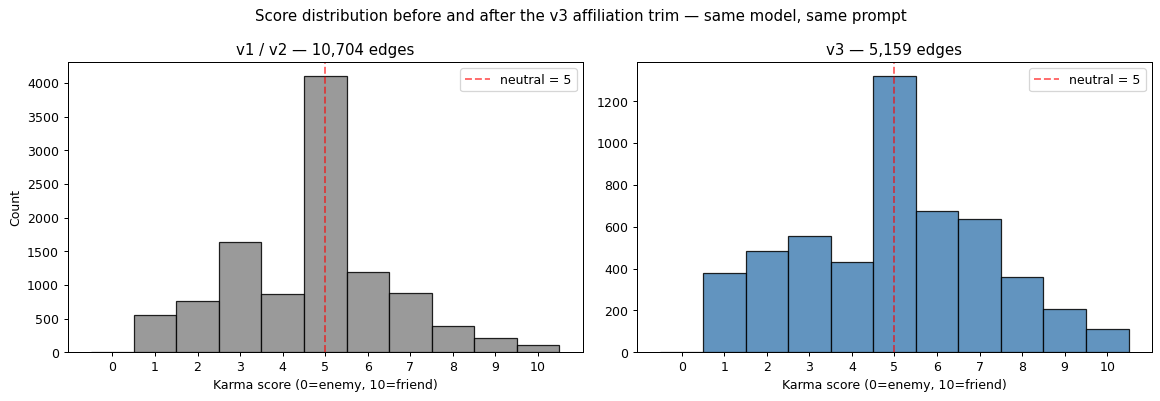

  v1/v2  n=10,704   at 5:  38.4%   in [4,6]:  57.5%   strong:  19.0%   mean: 4.71
  v3     n= 5,159   at 5:  25.6%   in [4,6]:  47.0%   strong:  29.8%   mean: 4.98


In [15]:
# Load both karma datasets to show the v1/v2 -> v3 signal-quality improvement
karma_v1 = pd.read_csv('../csvs/karma_edges.csv')
karma_v1['karma_score'] = pd.to_numeric(karma_v1['karma_score'], errors='coerce')
karma_v1 = karma_v1.dropna(subset=['karma_score'])

karma = pd.read_csv('../csvs/karma_edges_v3.csv')
karma['karma_score'] = pd.to_numeric(karma['karma_score'], errors='coerce')
karma = karma.dropna(subset=['karma_score'])

fig, (ax_v1, ax_v3) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
bins = np.arange(-0.5, 11.5, 1)

ax_v1.hist(karma_v1['karma_score'], bins=bins, color='#888', edgecolor='black', alpha=0.85)
ax_v1.axvline(5, color='red', linestyle='--', alpha=0.6, label='neutral = 5')
ax_v1.set_title(f'v1 / v2 — {len(karma_v1):,} edges'); ax_v1.set_xticks(range(11))
ax_v1.set_xlabel('Karma score (0=enemy, 10=friend)'); ax_v1.set_ylabel('Count')
ax_v1.legend(loc='upper right')

ax_v3.hist(karma['karma_score'], bins=bins, color='steelblue', edgecolor='black', alpha=0.85)
ax_v3.axvline(5, color='red', linestyle='--', alpha=0.6, label='neutral = 5')
ax_v3.set_title(f'v3 — {len(karma):,} edges'); ax_v3.set_xticks(range(11))
ax_v3.set_xlabel('Karma score (0=enemy, 10=friend)')
ax_v3.legend(loc='upper right')

plt.suptitle('Score distribution before and after the v3 affiliation trim — same model, same prompt')
plt.tight_layout(); plt.show()

for label, kdf in [('v1/v2', karma_v1), ('v3   ', karma)]:
    p5 = (kdf['karma_score'] == 5).mean()
    near5 = ((kdf['karma_score'] >= 4) & (kdf['karma_score'] <= 6)).mean()
    strong = (kdf['karma_score'].sub(5).abs() >= 3).mean()
    print(f'  {label}  n={len(kdf):>6,}   at 5: {p5:>6.1%}   in [4,6]: {near5:>6.1%}   '
          f'strong: {strong:>6.1%}   mean: {kdf["karma_score"].mean():.2f}')

#### House-pair heatmap — the rigorous backbone
We collapse the 200×200 directed adjacency to ≈ 15×15 by averaging karma per house pair. The diagonal is intra-house feeling (Cersei vs Tyrion-style infighting); off-diagonal is inter-house feeling (Lannister vs Stark). Cells show `mean / n=count`. With the neutrality bias acknowledged, this view is robust precisely because averaging over many edges *will* surface real preferences even when individual edges are noisy.

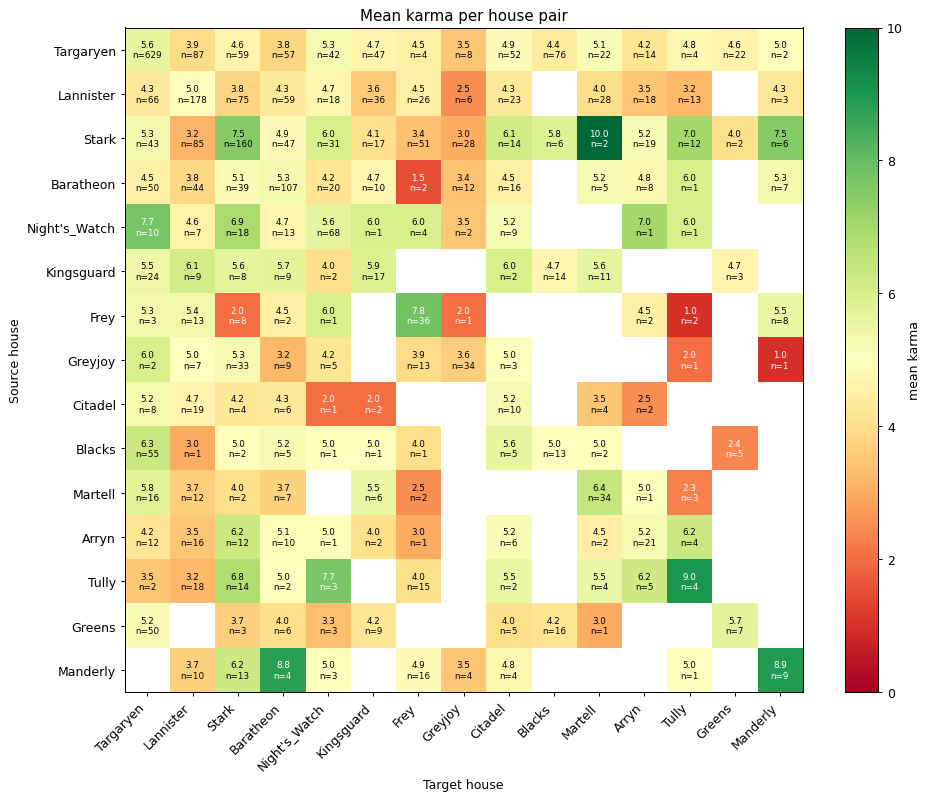

In [16]:
karma_h = karma.copy()
karma_h['source_house'] = karma_h['source_id'].map(primary_house)
karma_h['target_house'] = karma_h['target_id'].map(primary_house)
karma_h = karma_h[(karma_h['source_house'] != '') & (karma_h['target_house'] != '')]

house_e = Counter(karma_h['source_house']) + Counter(karma_h['target_house'])
top_h = [h for h, _ in house_e.most_common(15)]
karma_h = karma_h[karma_h['source_house'].isin(top_h) & karma_h['target_house'].isin(top_h)]

mean_mat = karma_h.pivot_table(index='source_house', columns='target_house', values='karma_score', aggfunc='mean')
cnt_mat = karma_h.pivot_table(index='source_house', columns='target_house', values='karma_score', aggfunc='count')
mean_mat = mean_mat.reindex(index=top_h, columns=top_h)
cnt_mat = cnt_mat.reindex(index=top_h, columns=top_h).fillna(0)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(mean_mat.values, cmap='RdYlGn', norm=TwoSlopeNorm(vmin=0, vcenter=5, vmax=10), aspect='auto')
ax.set_xticks(range(len(top_h))); ax.set_xticklabels([h.replace('House_', '') for h in top_h], rotation=45, ha='right')
ax.set_yticks(range(len(top_h))); ax.set_yticklabels([h.replace('House_', '') for h in top_h])
ax.set_xlabel('Target house'); ax.set_ylabel('Source house')
ax.set_title('Mean karma per house pair')
for i in range(len(top_h)):
    for j in range(len(top_h)):
        m = mean_mat.iloc[i, j]; c = int(cnt_mat.iloc[i, j])
        if c > 0 and not np.isnan(m):
            color = 'white' if abs(m - 5) > 2.5 else 'black'
            ax.text(j, i, f'{m:.1f}\nn={c}', ha='center', va='center', fontsize=7, color=color)
plt.colorbar(im, ax=ax, label='mean karma'); plt.tight_layout(); plt.show()


#### Asymmetry — the novelty that survives the neutrality bias
Mean-of-5 cancels out when many edges are noisy. Asymmetry doesn't. For every pair where the LLM produced both A→B and B→A scores, we plot `(score(A→B), score(B→A))`. Points on the diagonal are mutual; points far off-diagonal are one-sided. The most asymmetric pairs are annotated.

This is the rubric novelty: the asymmetry pattern is information that the unsigned co-mention graph **cannot represent**, because edges are undirected and binary. The LLM scoring earns its keep by surfacing it.

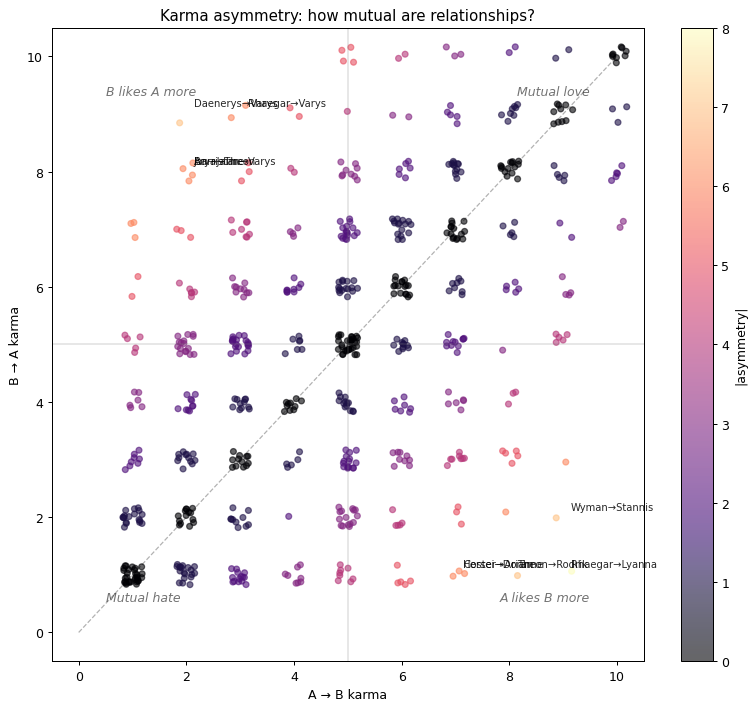

Top 10 asymmetric pairs:
  Rhaegar Targaryen          → Lyanna Stark                9  vs  1
  Wyman Manderly             → Stannis Baratheon           9  vs  2
  Daenerys Targaryen         → Varys                       2  vs  9
  Theon Greyjoy              → Rodrik Cassel               8  vs  1
  Hoster Tully               → Arianne Martell             7  vs  1
  Jon Arryn                  → Jaime Lannister             2  vs  8
  Arya Stark                 → Theon Greyjoy               2  vs  8
  Cersei Lannister           → Doran Martell               7  vs  1
  Barristan Selmy            → Varys                       2  vs  8
  Rhaegar Targaryen          → Varys                       3  vs  9


In [17]:
DG = nx.DiGraph()
for _, row in karma.iterrows():
    DG.add_edge(row['source_id'], row['target_id'], score=float(row['karma_score']))

edge_score = {(u, v): d['score'] for u, v, d in DG.edges(data=True)}
pairs = []; seen = set()
for (u, v), s_uv in edge_score.items():
    if (v, u) in edge_score and (v, u) not in seen and (u, v) not in seen:
        pairs.append((u, v, s_uv, edge_score[(v, u)]))
        seen.add((u, v)); seen.add((v, u))

xs = np.array([s for _, _, s, _ in pairs]); ys = np.array([s for _, _, _, s in pairs])
asym = np.abs(xs - ys)
rng2 = np.random.default_rng(42)
xj = xs + rng2.uniform(-0.18, 0.18, len(xs)); yj = ys + rng2.uniform(-0.18, 0.18, len(ys))

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(xj, yj, c=asym, cmap='magma', alpha=0.6, s=22)
ax.plot([0, 10], [0, 10], 'k--', alpha=0.3, linewidth=1)
ax.axhline(5, color='grey', alpha=0.2); ax.axvline(5, color='grey', alpha=0.2)
top_asym = sorted(pairs, key=lambda p: abs(p[2] - p[3]), reverse=True)[:10]
for u, v, s_uv, s_vu in top_asym:
    a = name_by_id.get(u, u).split()[0]; b = name_by_id.get(v, v).split()[0]
    ax.annotate(f'{a}→{b}', (s_uv, s_vu), xytext=(6, 6), textcoords='offset points', fontsize=8, alpha=0.85)
ax.set_xlim(-0.5, 10.5); ax.set_ylim(-0.5, 10.5)
ax.set_xlabel('A → B karma'); ax.set_ylabel('B → A karma')
ax.set_title('Karma asymmetry: how mutual are relationships?')
plt.colorbar(sc, ax=ax, label='|asymmetry|')
ax.text(0.5, 9.5, 'B likes A more', alpha=0.55, style='italic', va='top')
ax.text(9.5, 0.5, 'A likes B more', alpha=0.55, style='italic', ha='right', va='bottom')
ax.text(0.5, 0.5, 'Mutual hate', alpha=0.55, style='italic', va='bottom')
ax.text(9.5, 9.5, 'Mutual love', alpha=0.55, style='italic', ha='right', va='top')
plt.tight_layout(); plt.show()

print('Top 10 asymmetric pairs:')
for u, v, s_uv, s_vu in top_asym:
    print(f'  {name_by_id.get(u, u):26s} → {name_by_id.get(v, v):26s}  {s_uv:.0f}  vs  {s_vu:.0f}')


#### House-level karma rankings — who hates whom on average

Averaging the per-edge scores up to the *house* level smooths the neutrality bias because each pair-of-houses cell aggregates many directed edges. With the v3 dataset the cells are denser and the rankings sharper than they were in v1/v2.

Three things to look at:

1. **Most unfriendly cross-house pairs** (mean karma across both directions). The bottom of this list maps cleanly to the canon's standing feuds.
2. **Most friendly cross-house pairs**. The top is dominated by recurring marriage alliances and joint causes.
3. **Intra-house cohesion** (mean karma among members of the *same* house). Low = internal vendettas; high = a unified bloc.

Filters: cross-house pairs need ≥ 5 directed edges to count; intra-house rankings need ≥ 3. Both keep one-shot LLM noise from making a marginal pair look like a sworn enemy.

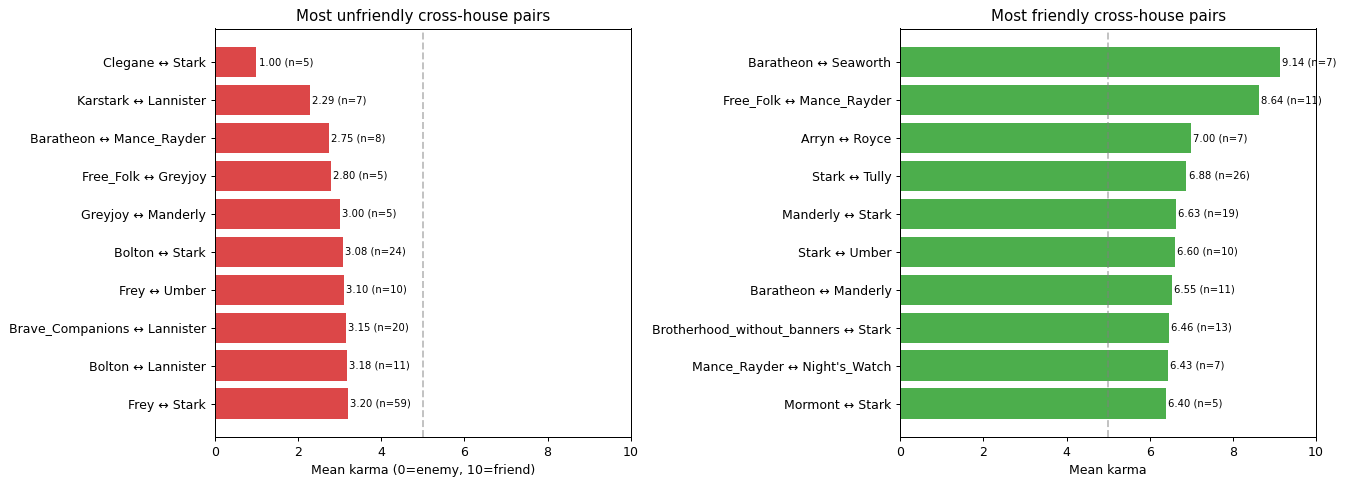

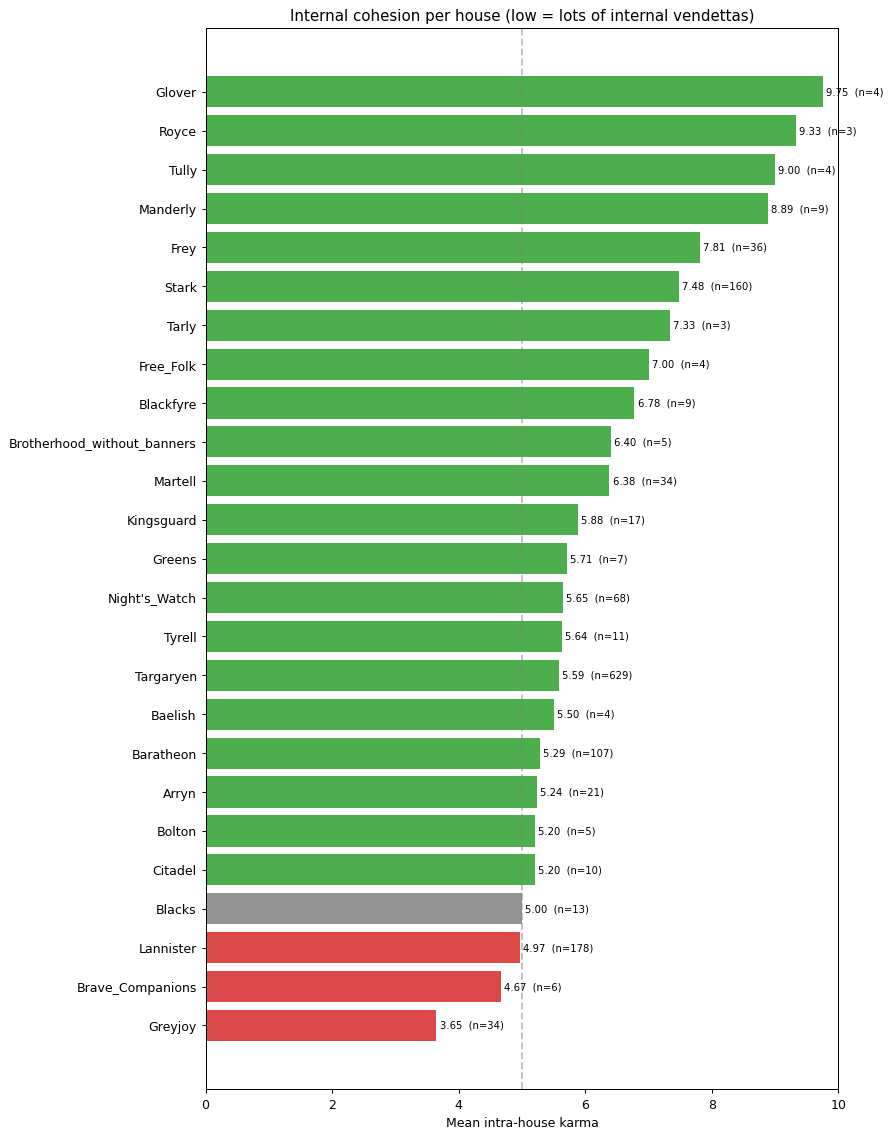

In [18]:
karma_h = karma.copy()
karma_h['source_house'] = karma_h['source_id'].map(primary_house)
karma_h['target_house'] = karma_h['target_id'].map(primary_house)
karma_h = karma_h[(karma_h['source_house'] != '') & (karma_h['target_house'] != '')]
karma_h['is_intra'] = karma_h['source_house'] == karma_h['target_house']

# Cross-house pairs (unordered, averaged across both directions)
karma_h['pair'] = karma_h.apply(lambda r: tuple(sorted([r['source_house'], r['target_house']])), axis=1)
cross = karma_h[~karma_h['is_intra']]
pair_stats = (cross.groupby('pair')['karma_score']
              .agg(mean='mean', n='count').reset_index())
pair_stats['house_A'] = pair_stats['pair'].apply(lambda p: p[0].replace('House_', ''))
pair_stats['house_B'] = pair_stats['pair'].apply(lambda p: p[1].replace('House_', ''))
pair_stats = pair_stats[pair_stats['n'] >= 5].drop(columns='pair')

# Intra-house
intra = karma_h[karma_h['is_intra']]
intra_stats = (intra.groupby('source_house')['karma_score']
               .agg(mean='mean', n='count').reset_index()
               .rename(columns={'source_house': 'house'}))
intra_stats['house'] = intra_stats['house'].str.replace('House_', '', regex=False)
intra_stats = intra_stats[intra_stats['n'] >= 3].sort_values('mean')

fig, (ax_u, ax_f) = plt.subplots(1, 2, figsize=(15, 5.5))

unfriendly = pair_stats.nsmallest(10, 'mean').iloc[::-1]
labels_u = [f'{a} \u2194 {b}' for a, b in zip(unfriendly['house_A'], unfriendly['house_B'])]
ax_u.barh(labels_u, unfriendly['mean'], color='#d62728', alpha=0.85)
for i, (m, n) in enumerate(zip(unfriendly['mean'], unfriendly['n'])):
    ax_u.text(m + 0.05, i, f'{m:.2f} (n={int(n)})', va='center', fontsize=8)
ax_u.axvline(5, color='grey', linestyle='--', alpha=0.5)
ax_u.set_xlim(0, 10); ax_u.set_xlabel('Mean karma (0=enemy, 10=friend)')
ax_u.set_title('Most unfriendly cross-house pairs')

friendly = pair_stats.nlargest(10, 'mean').iloc[::-1]
labels_f = [f'{a} \u2194 {b}' for a, b in zip(friendly['house_A'], friendly['house_B'])]
ax_f.barh(labels_f, friendly['mean'], color='#2ca02c', alpha=0.85)
for i, (m, n) in enumerate(zip(friendly['mean'], friendly['n'])):
    ax_f.text(m + 0.05, i, f'{m:.2f} (n={int(n)})', va='center', fontsize=8)
ax_f.axvline(5, color='grey', linestyle='--', alpha=0.5)
ax_f.set_xlim(0, 10); ax_f.set_xlabel('Mean karma')
ax_f.set_title('Most friendly cross-house pairs')
plt.tight_layout(); plt.show()

# Intra-house bar chart
fig, ax = plt.subplots(figsize=(10, 0.45 * len(intra_stats) + 1.5))
colors = ['#d62728' if m < 5 else '#2ca02c' if m > 5 else 'grey' for m in intra_stats['mean']]
ax.barh(intra_stats['house'], intra_stats['mean'], color=colors, alpha=0.85)
for i, (_, row) in enumerate(intra_stats.iterrows()):
    ax.text(row['mean'] + 0.05, i, f"{row['mean']:.2f}  (n={int(row['n'])})",
            va='center', fontsize=8)
ax.axvline(5, color='grey', linestyle='--', alpha=0.5)
ax.set_xlim(0, 10); ax.set_xlabel('Mean intra-house karma')
ax.set_title('Internal cohesion per house (low = lots of internal vendettas)')
plt.tight_layout(); plt.show()

**Deeper karma views in `Karma/karma_viz.ipynb`.** Three richer visualisations live in the dedicated karma notebook rather than inline here, to keep the explainer scannable:

- **Filtered force-directed graph** — only extreme edges (\|score−5\| ≥ 3), with the friend/enemy split colored in.
- **Per-character ego networks** for 10 main characters — Jon, Tyrion, Cersei, etc.
- **Geographic placement on Westeros** — karma edges drawn on the schematic map, with a split panel separating enemies (red) and friends (green). This is the view that most cleanly shows that the dramatic conflict in the books is *also* a geographic one — the Riverlands and the Crownlands are the densest red zones; the Iron Islands sit largely apart.

## 4. Discussion

### What went well
**Real, but coalition-sized, community structure.** The configuration-model null in §3.1 confirms the Louvain modularity is many standard deviations above chance — the network is not noise. The structure isn't house- or region-aligned in a naive sense (ARI ≈ 0.06, homogeneity ≈ 0.25), but it is structural in a *consistent* sense: **completeness ≫ homogeneity**, meaning the network reliably groups a given house's members together while bundling them into larger coalition-sized communities. The headline isn't "Louvain rediscovers Westeros"; it's *the unit Louvain rediscovers is bigger than a house, and we can name why.*

**Three failure modes diagnosed by their own metrics.** Orders (NW, Citadel, Faith, Kingsguard) bridge house boundaries — the largest NW-dominant community contains characters from 10+ houses. Long-running dynasties (Targaryen, Stark) fragment across 3–4 Louvain communities corresponding to publication eras because the wiki collapses 5,000 years into one timeless graph. And per-community degree analysis shows the largest communities sit above the mean-equals-median line — they're held together by one or two hubs, not by grass-roots interaction. Each of these is documented with a specific diagnostic (`community_vs_allegiance.ipynb` §11, `allegiance_story.ipynb` §4).

**Text and network signals reinforce each other.** TF-IDF per house surfaces vocabulary that semantically matches each house's modal Louvain community: Stark vocabulary clusters with the Northern coalition community, Targaryen vocabulary with the Crownlands community, etc. Two independent measurement pipelines converging is the strongest evidence that the underlying structure is real and not a methodological artefact.

**The LLM extension produced one genuinely novel result.** Asymmetric karma — A→B systematically scoring differently than B→A — is information the unsigned co-mention graph cannot represent at all. The top-10 asymmetric pairs map cleanly to the dramatic structure of the novels (Cersei's contempt for Tyrion, the resigned-vs-violent dynamic in Bolton↔Stark, the courtier-vs-king imbalances around Joffrey).

**Beyond-course extensions, named explicitly.** We use sklearn's ARI / NMI / homogeneity / completeness / V-measure to *quantify* the comparison the course's confusion matrix shows visually; we built an LLM scoring pipeline; we redesigned the affiliation scraper to use an *include-list* parser to avoid navbox / family leakage. Each extension is justified in §3.

### What is missing — and why

**Temporal information.** The wiki collapses 5,000 in-universe years into one static graph. The Crownlands community is in practice a *Targaryen-across-all-time* cluster: Aegon I, Jaehaerys I, Aerys II, and Daenerys all sit in the same community despite never having interacted. A proper fix would scrape `Born` and `Died` from each infobox and drop edges where lifetimes do not overlap. We designed this fix and ran a partial implementation in `timeline works/`, but a follow-up notebook (`05_book_segmentation_research.ipynb`) showed AWOIAF doesn't expose a reliable per-book signal — the per-character section headings record *mentions in recent books*, not *appearances*. The temporal smear is therefore a documented limitation, not a fixed problem. Every conclusion about dynastic houses (Targaryen especially) should be read with this caveat in mind.

**Coverage caveat.** Even after the Baratheon cadet-branch merge, the top-14 primary assignments cover only **41% of the cast** (28.8% if restricted to noble houses). The remaining ~59% — minor houses, unaffiliated nobles, smallfolk — sit in the muted gray of every top-N map and don't enter the per-house purity metrics. Our conclusions about *which* groups cluster well are conclusions about the **loudest 41%** of the cast.

**LLM neutrality bias.** The karma score distribution has a clear spike at 5. The LLM defaults to neutral when the bio doesn't give it enough evidence to call a relationship friend or enemy — and many bios of minor characters don't. We mitigate by leading with the **asymmetric** view (which is robust to neutrality bias) rather than the global mean. A tighter prompt that explicitly instructed *avoid 5 unless you have direct evidence* would likely shift the distribution toward usable signal, at the cost of more spurious extreme scores.

**Single-snapshot LLM.** We ran each character once with Haiku. A more rigorous design would ensemble multiple LLMs, sample multiple times with non-zero temperature, and pool the median — at meaningful cost.

**No alternative community algorithm tested.** We ran Louvain at its default resolution only. Infomap or Leiden, or a multi-resolution sweep, might surface communities that match houses more cleanly — we don't know, and that's a real gap.

**No causal interpretation.** Modularity, ARI, and purity all measure correlation between graph structure and ground-truth labels. None of them say *region causes interaction* — only that the two co-vary in our data. The fictional setting protects us from most causal mistakes a real-world study would face, but the framing limitation remains.

**Co-mention edges are unsigned.** Two warring characters who constantly interact (Cersei ↔ Tyrion) generate the same edge as two close allies (Cat ↔ Ned). Without sign or direction, the partition cannot distinguish alliance from enmity — it only sees narrative density. The LLM karma layer partially patches this for top-200 characters; the rest of the graph remains unsigned.

### Ethical reflection
Every subject in this dataset is fictional, so the usual concerns about privacy, consent, and bias against named individuals do not apply directly. Two analogues still do:

1. **Source bias.** AWOIAF is an editor-curated wiki. Editors put more time into popular characters than minor ones — so the LLM-scored relationships favour main-cast feuds that editors documented in depth. Less-documented characters appear in the graph as thinly described, low-degree nodes with mostly neutral karma scores; we are systematically blind to relationships the editors didn't bother to record.
2. **LLM training data leakage.** Claude has seen *A Song of Ice and Fire* during training. Its karma scoring is not an independent reading of the bios we provided — it is informed by background knowledge of the books. This is helpful (the LLM correctly identifies that Joffrey is malicious toward Sansa even from one paragraph), but it is also opaque (we cannot separate *what the bio said* from *what Claude already knew*). For replication on a less-canonical fictional dataset (e.g., a smaller wiki), this method would degrade quickly.

### Future work
1. Scrape `Born`/`Died`, parse `XX AC` / `XX BC`, drop edges where active eras don't overlap. This is the single highest-impact improvement to the network — it would split the Crownlands and Order communities into era-coherent sub-clusters and meaningfully change the agreement metrics.
2. Add a directed weighted edge layer derived from the *number* of times A is mentioned in B's bio (currently we treat the affiliation as binary).
3. Apply Infomap or Leiden as a second community-detection algorithm. Disagreements between Louvain and these are themselves informative about which communities are robust to algorithmic choice.
4. Re-run the LLM with a tighter prompt and several models; pool the median karma per directed pair to attenuate the neutrality bias.
5. Re-run the analysis after collapsing the long tail of minor houses into bannerman groupings — would lift the coloured coverage beyond 41% and may improve homogeneity.

---

*Code for every analysis in this notebook is reproducible from the raw scraped CSVs. The original scrapers (`scrape_characters_v3.ipynb`, `scrape_character_bios.ipynb`) regenerate the data, and the analysis notebooks (`network_stats.ipynb`, `community_vs_region.ipynb`, `House_TF_IDF.ipynb`, etc.) reproduce each section in greater detail. All code is at the project's GitHub repository.*